# Diplomado en Ciencia de Datos
# Proyecto Módulo 4
# Aldo Alejandro Gallegos Ruiz

# Imégenes Satelitales CNN

### Carga de módulos

In [1]:
# Data Wrangling
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Modeling
import tensorflow as tf
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Data Visualization
# import cufflinks as cf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import shutil
import random
import cufflinks as cf
import re

# Image manipulation
import cv2
from PIL import Image
import matplotlib.image as mpimg
import keras.layers as layers

# Configuración del notebook
# cf.go_offline()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.FATAL)
pd.set_option("display.max_colwidth", None)

### Reunir las imágenes en una ruta

In [2]:
path="C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/images"
path_dest = "C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img"

if not os.path.exists(path_dest):
    os.makedirs(path_dest)

for label in os.listdir(path):
    carpeta_label = os.path.join(path, label)
    
    for imagen in os.listdir(carpeta_label):
        ruta_imagen = os.path.join(carpeta_label, imagen)
        destino_imagen = os.path.join(path_dest, imagen)

        shutil.move(ruta_imagen, destino_imagen)

### Generación de carpetas con shutil

Generar carpetas train y test que contienen a su vez las capetas de las imágenes de cada personaje

carpeta_train = os.path.join(path_dest, "train")
carpeta_test = os.path.join(path_dest, "test")

if not os.path.exists(path_dest):
    print(f"La carpeta {path_dest} no existe.")
else:
    if not os.path.exists(carpeta_train):
        os.makedirs(carpeta_train)
    if not os.path.exists(carpeta_test):
        os.makedirs(carpeta_test)
    
    imagenes = [archivo for archivo in os.listdir(path_dest) if archivo.endswith(".jpg")]
    random.shuffle(imagenes)
    nombres_lugares = {archivo.split('_')[0] for archivo in imagenes}
    
    for personaje in nombres_lugares:
        os.makedirs(os.path.join(carpeta_train, personaje), exist_ok=True)
        os.makedirs(os.path.join(carpeta_test, personaje), exist_ok=True)
    
    indice_division = int(0.8 * len(imagenes))
    
    imagenes_train = imagenes[:indice_division]
    imagenes_test = imagenes[indice_division:]
    
    def organizar_imagenes(imagenes, carpeta_destino):
        for archivo in imagenes:
            nombre_lugar = archivo.split('_')[0]
            carpeta_lugar = os.path.join(carpeta_destino, nombre_lugar)
            
            origen = os.path.join(path_dest, archivo)
            destino = os.path.join(carpeta_lugar, archivo)
            shutil.move(origen, destino)
    
    organizar_imagenes(imagenes_train, carpeta_train)
    organizar_imagenes(imagenes_test, carpeta_test)
    
    print("Las imágenes han sido divididas en 'train' y 'test' y organizadas en carpetas según el personaje.")


### Preparación de carpetas

In [3]:
if not os.path.exists("./models_project/"):
    os.mkdir("./models_project/")

### Validación de hardware

In [4]:
print('Tensorflow version:', tf.__version__)
print('Is using GPU?', tf.config.list_physical_devices())

Tensorflow version: 2.17.0
Is using GPU? [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Data Wrangling

### Obtención de datos

### Establecimiento de rutas

In [5]:
train_dir = os.path.join(path, 'train')

In [6]:
test_dir = os.path.join(path, 'test')

### Guardar rutas de las imágenes

In [7]:
carpeta_train = os.path.join(path_dest, "train")
carpeta_test = os.path.join(path_dest, "test")

lista_train_rutas = []
lista_test_rutas = []

def generar_y_guardar_rutas(carpeta_base, tipo, lista_rutas):
    for personaje in os.listdir(carpeta_base):
        carpeta_personaje = os.path.join(carpeta_base, personaje)
        if os.path.isdir(carpeta_personaje):
            nombre_variable = f"{tipo}_{personaje}_dir"
            globals()[nombre_variable] = carpeta_personaje
            lista_rutas.append(globals()[nombre_variable])

generar_y_guardar_rutas(carpeta_train, "train", lista_train_rutas)
generar_y_guardar_rutas(carpeta_test, "test", lista_test_rutas)


### Tamaño de los conjuntos de datos

Train

In [8]:
for list in lista_train_rutas:
    print(f"{os.path.basename(list)}: {len(os.listdir(list))}")

airport: 5356
bridge: 6428
commercial: 6296
dense: 7300
farmland: 6392
freeway: 6404
ground: 6388
harbor: 6396
industrial: 5196
intersection: 6500
mobile: 6388
overpass: 6508
park: 3948
parking: 6348
parkway: 6552
railway: 12196
roundabout: 5276
shipping: 6448
sparse: 4220
stadium: 6288
storage: 6488
terrace: 6532
vegetable: 6720


Test

In [9]:
for list in lista_test_rutas:
    print(f"{os.path.basename(list)}: {len(os.listdir(list))}")

airport: 357
bridge: 393
commercial: 434
dense: 463
farmland: 411
freeway: 407
ground: 411
harbor: 410
industrial: 318
intersection: 375
mobile: 411
overpass: 381
park: 245
parking: 421
parkway: 402
railway: 743
roundabout: 321
shipping: 396
sparse: 281
stadium: 396
storage: 386
terrace: 375
vegetable: 424


In [10]:
train_normal_names = os.listdir(test_airport_dir)

In [11]:
len(train_normal_names)

357

### Ver desbalanceo

In [12]:
test_not_airport = [list for list in lista_test_rutas if list not in test_airport_dir]

len_test_not_airport=0
for test in test_not_airport:
    len_test_not_airport=len_test_not_airport+len(os.listdir(test))


In [13]:
len_test_not_airport

8804

In [14]:
train_not_airport = [list for list in lista_train_rutas if list not in train_airport_dir]

len_train_not_airport=0
for train in train_not_airport:
    len_train_not_airport=len_train_not_airport+len(os.listdir(train))

In [15]:
len_train_not_airport

141212

In [16]:
len(test_airport_dir)+len(test_not_airport), len(test_airport_dir) / (len(test_airport_dir)+len_test_not_airport)

(108, 0.00967379077615298)

In [17]:
len(train_airport_dir)+len(train_not_airport), len(train_airport_dir) / (len(train_airport_dir)+len_train_not_airport)

(109, 0.0006157156101600153)

No hay desvalenceo

In [18]:
0.00967379077615298-0.002458321559762645

0.007215469216390335

In [19]:
os.listdir(train_airport_dir)[:5]

['airport_0.jpg',
 'airport_0_f.jpg',
 'airport_0_r30.jpg',
 'airport_0_s30.jpg',
 'airport_1.jpg']

### Data visualization

In [20]:
airport_pic = [os.path.join(train_airport_dir, filename) for filename in os.listdir(train_airport_dir)[:5]]
stadium_pic = [os.path.join(train_stadium_dir, filename) for filename in os.listdir(train_stadium_dir)[:5]]

In [21]:
full_pic = airport_pic+stadium_pic

<Figure size 2400x2400 with 0 Axes>

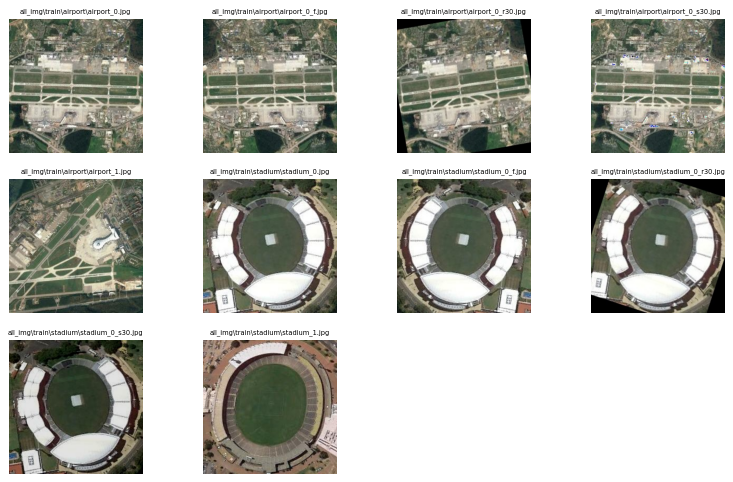

In [22]:
ROWS = 4
COLS = 4
fig = plt.gcf()
fig.set_size_inches(24, 24)
plt.figure(figsize=(12, 10), dpi=80)
for i, img_path in enumerate(full_pic):
    data = img_path.split('/')[-1]
    sp = plt.subplot(ROWS, COLS, i+1)
    sp.axis('Off')
    img = mpimg.imread(img_path)
    sp.set_title(data, fontsize=6)
    plt.imshow(img, cmap='gray')
plt.show()

## Data Augmentation

Hacer flip a la imagen

In [23]:
def flip_image(image_path, destiny_path):
    original = cv2.imread(image_path)
    flipped = cv2.flip(original, 10)
    cv2.imwrite(destiny_path, flipped)

In [24]:
path_img_example='C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img/test/airport/airport_1060.jpg'
flip_image(path_img_example, "./flipped.jpg")

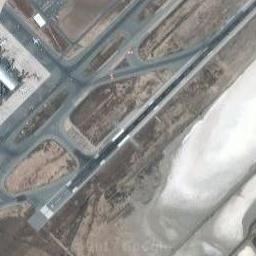

In [25]:
Image.open(path_img_example)

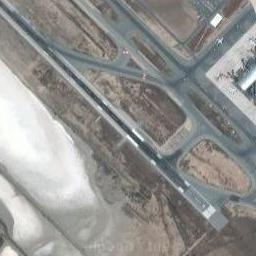

In [26]:
Image.open("./flipped.jpg")

Rotar la imagen

In [27]:
def rotation(image_path, destiny_path, angle):
    img = cv2.imread(image_path)
    angle = int(random.uniform(-angle, angle))
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((int(w/2), int(h/2)), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))
    cv2.imwrite(destiny_path, img)

In [28]:
rotation(path_img_example, "./rotated.jpg", 20)

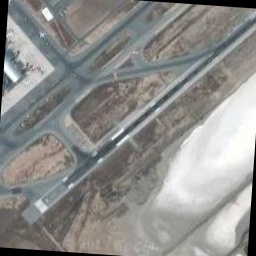

In [29]:
Image.open("./rotated.jpg")

Modificar los canales

In [30]:
def channel_shift(image_path, destiny_path, value):
    img = cv2.imread(image_path)
    value = int(random.uniform(-value, value))
    img = img + value
    img[:,:,:][img[:,:,:]>255]  = 255
    img[:,:,:][img[:,:,:]<0]  = 0
    img = img.astype(np.uint8)
    cv2.imwrite(destiny_path, img)

In [31]:
channel_shift(path_img_example, "cs.jpg", 20)

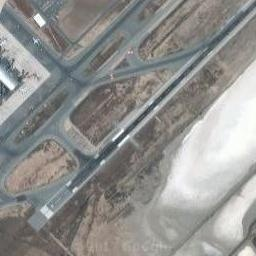

In [32]:
Image.open("cs.jpg")

### Preparación de los sets

In [33]:
source = 'C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img/'
train_dir = os.path.join(source, 'train')
validate_dir = os.path.join(source, 'validate')

In [34]:
os.listdir(train_dir)

['airport',
 'bridge',
 'commercial',
 'dense',
 'farmland',
 'freeway',
 'ground',
 'harbor',
 'industrial',
 'intersection',
 'mobile',
 'overpass',
 'park',
 'parking',
 'parkway',
 'railway',
 'roundabout',
 'shipping',
 'sparse',
 'stadium',
 'storage',
 'terrace',
 'vegetable']

### Aplicar Data Augmentation

for labels in os.listdir(train_dir):
    label=  os.path.join(train_dir, labels)

    for img in os.listdir(label):
        new_train = os.path.join(label, img)
        flip_image(new_train, new_train.replace(".jpg", "_f.jpg"))
        rotation(new_train, new_train.replace(".jpg", f"_r{30}.jpg"), 30)
        channel_shift(new_train, new_train.replace(".jpg", f"_s{30}.jpg"), 30)

# Dataframe

In [35]:
os.listdir(path_dest)

['test', 'train']

In [36]:
carpeta=[]

for sets in os.listdir(path_dest):

    path_sets = os.path.join(path_dest, sets)

    for label in os.listdir(path_sets):

        path_labels = os.path.join(path_sets, label)

        for img in os.listdir(path_labels):
            path_img=os.path.join(path_labels,img)
            carpeta.append({"path":path_img, "label":label, "set":sets})

In [37]:
df=pd.DataFrame(carpeta)

In [38]:
df

,path,label,set
0,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\test\airport\airport_1006.jpg,airport,test
1,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\test\airport\airport_1007.jpg,airport,test
2,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\test\airport\airport_1008.jpg,airport,test
3,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\test\airport\airport_1009.jpg,airport,test
4,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\test\airport\airport_1014.jpg,airport,test
...,...,...,...
155724,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\train\vegetable\vegetable_greenhouse_999_r30.jpg,vegetable,train
155725,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\train\vegetable\vegetable_greenhouse_999_s30.jpg,vegetable,train
155726,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\train\vegetable\vegetable_greenhouse_9_f.jpg,vegetable,train
155727,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/all_img\train\vegetable\vegetable_greenhouse_9_r30.jpg,vegetable,train


# Collage 

def get_place_base(filename):
    match = re.match(r"(.*_\d+)", os.path.splitext(filename)[0])
    if match:
        return match.group(1)
    return None

df["place_id"]=df['path'].apply(lambda x: get_place_base(os.path.basename(x)))


grouped_images = {}

for index, row in df.iterrows():
    place_base = row['place_id']
    if place_base not in grouped_images:
        grouped_images[place_base] = []
    grouped_images[place_base].append(row['path'])

In [39]:
ruta_collage ='C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage'
if not os.path.exists(ruta_collage):
    os.makedirs(ruta_collage)

new_paths = []

for place_base, paths in grouped_images.items():
    # Cargar las imágenes
    images = [Image.open(img_path) for img_path in paths]
    
    # Obtener el tamaño de la primera imagen
    width, height = images[0].size
    
    # Crear un lienzo en blanco para el collage
    if len(images) == 1:
        collage = images[0]
    elif len(images) >= 4:
        collage = Image.new('RGB', (width * 2, height * 2))
        collage.paste(images[0], (0, 0))
        collage.paste(images[1], (width, 0))
        collage.paste(images[2], (0, height))
        collage.paste(images[3], (width, height))
    
    # Obtener la ruta de la primera imagen para mantener la estructura
    original_path = paths[0]
    partes = original_path.split(os.sep)

    # Crear la ruta del collage
    new_img_path = os.path.join(ruta_collage, partes[-3], partes[-2], f"collage_{place_base}.jpg")
    
    # Asegurarse de que el directorio del collage exista
    os.makedirs(os.path.dirname(new_img_path), exist_ok=True)
    
    # Guardar la imagen combinada
    collage.save(new_img_path)
    
    # Almacenar la nueva ruta
    new_paths.append(new_img_path)


# Dataframe Final

# Crear un nuevo DataFrame con las rutas de los collages
df_collages = pd.DataFrame({'collage_path': new_paths})

In [40]:
carpeta=[]

for sets in os.listdir(ruta_collage):

    path_sets = os.path.join(ruta_collage, sets)

    for label in os.listdir(path_sets):

        path_labels = os.path.join(path_sets, label)

        for img in os.listdir(path_labels):
            path_img=os.path.join(path_labels,img)
            carpeta.append({"path":path_img, "label":label, "set":sets})

In [41]:
df=pd.DataFrame(carpeta)

In [42]:
df

,path,label,set
0,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\test\airport\collage_airport_1006.jpg,airport,test
1,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\test\airport\collage_airport_1007.jpg,airport,test
2,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\test\airport\collage_airport_1008.jpg,airport,test
3,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\test\airport\collage_airport_1009.jpg,airport,test
4,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\test\airport\collage_airport_1014.jpg,airport,test
...,...,...,...
45800,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\train\vegetable\collage_vegetable_greenhouse_995.jpg,vegetable,train
45801,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\train\vegetable\collage_vegetable_greenhouse_996.jpg,vegetable,train
45802,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\train\vegetable\collage_vegetable_greenhouse_997.jpg,vegetable,train
45803,C:/Users/aldol/Programming/Diplo/Modulo_4/Datos_Modulo_4/proyecto/collage\train\vegetable\collage_vegetable_greenhouse_998.jpg,vegetable,train


## Visualización gráfica

In [43]:
df["label"].value_counts().iplot(kind="bar")

In [44]:
df["set"].value_counts().iplot(kind="bar")

## Path's de train y test

In [45]:
train_dir = os.path.join(ruta_collage, 'train')
validate_dir = os.path.join(ruta_collage, 'test')

## Generadores

In [46]:
dgen_train = ImageDataGenerator(rescale=1./255,
                                validation_split=0.2,
                                zoom_range=0.2,
                                vertical_flip=True)

In [47]:
dgen_validation = ImageDataGenerator(rescale=1./255)

In [48]:
dgen_test = ImageDataGenerator(rescale=1./255)

In [49]:
TARGET_SIZE = (150, 150)
BATCH_SIZE = 72
CLASS_MODE = 'categorical'

In [50]:
train_generator = dgen_train.flow_from_directory(train_dir,
                                                 target_size=TARGET_SIZE,
                                                 subset='training',
                                                 batch_size=BATCH_SIZE,
                                                 class_mode=CLASS_MODE)

Found 29324 images belonging to 24 classes.


In [51]:
validation_generator = dgen_train.flow_from_directory(train_dir,
                                                      target_size=TARGET_SIZE,
                                                      subset='validation',
                                                      batch_size=BATCH_SIZE,
                                                      class_mode=CLASS_MODE)

Found 7318 images belonging to 24 classes.


In [52]:
test_generator = dgen_test.flow_from_directory(validate_dir,
                                               target_size=TARGET_SIZE,
                                               batch_size=BATCH_SIZE,
                                               class_mode=CLASS_MODE)

Found 9161 images belonging to 24 classes.


## Target

In [53]:
train_generator.class_indices

{'airport': 0,
 'bridge': 1,
 'commercial': 2,
 'dense': 3,
 'farmland': 4,
 'freeway': 5,
 'ground': 6,
 'harbor': 7,
 'industrial': 8,
 'intersection': 9,
 'mobile': 10,
 'overpass': 11,
 'park': 12,
 'parking': 13,
 'parkway': 14,
 'railway': 15,
 'railway_station': 16,
 'roundabout': 17,
 'shipping': 18,
 'sparse': 19,
 'stadium': 20,
 'storage': 21,
 'terrace': 22,
 'vegetable': 23}

#### Tamaño de los vectores de entrada

In [54]:
train_generator.image_shape

(150, 150, 3)

## Modelado

### Establecimiento de base

In [55]:
model = Sequential()

### Capas Convolucionales, Pooling y Dropout

In [56]:
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=train_generator.image_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

c:\Users\aldol\diplo\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [57]:
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

In [58]:
model.add(Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer="l2"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

In [59]:
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

In [60]:
model.add(Conv2D(384 , (3, 3), activation='relu')) #512
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3)) #0.25

### Capas densamente conectadas

In [61]:
model.add(Flatten())
model.add(Dense(200, activation='relu', kernel_regularizer="l2"))
model.add(Dropout(0.35))
model.add(Dense(len(train_generator.class_indices), activation='softmax', kernel_regularizer="l2"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3456)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       691,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         4,824 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,760 (7.51 MB)

 Trainable params: 1,969,760 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

### Parámetros de entrenamiento

In [62]:
model.compile(Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

### Callbacks

#### Early stopping

In [63]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)

#### Checkpoints

Guardar los resultados de val_accuracy cuando ejecutemos la CNN

In [64]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('models_project/model_project_{val_accuracy:.3f}.keras',
                                                save_best_only=True,
                                                save_weights_only=False,
                                                monitor='val_accuracy'
                                               )

### Entrenamiento del modelo

In [65]:
train_generator

In [66]:
history = model.fit(train_generator,
                    epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stopping, checkpoint])

Epoch 1/30


c:\Users\aldol\diplo\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



408/408 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.0742 - loss: 3.9722 - val_accuracy: 0.1712 - val_loss: 2.8770
Epoch 2/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - accuracy: 0.2145 - loss: 2.6889 - val_accuracy: 0.3101 - val_loss: 2.4596
Epoch 3/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.3449 - loss: 2.2948 - val_accuracy: 0.3818 - val_loss: 2.2049
Epoch 4/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.4149 - loss: 2.0891 - val_accuracy: 0.4075 - val_loss: 2.1347
Epoch 5/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 701s 2s/step - accuracy: 0.4578 - loss: 1.9531 - val_accuracy: 0.4699 - val_loss: 1.9507
Epoch 6/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 702s 2s/step - accuracy: 0.5063 - loss: 1.8140 - val_accuracy: 0.5112 - val_loss: 1.8471
Epoch 7/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 702s 2s/step - accuracy: 0.5342 - loss: 1.7345 - val_accuracy: 0.5342 - val_loss: 1.7646
Epoch 8/30
408/408 ━━━━━━━━━━━━━━━━━━━━ 702s 2s/step - accuracy: 0.5715 - loss: 1.6417 - val_accuracy: 0.543

## Evaluación de resultados

### Resultados de entrenamiento

In [67]:
results = pd.DataFrame(data = zip(history.history["loss"], history.history["val_loss"], history.history["accuracy"], history.history["val_accuracy"]), columns=["loss", "val_loss", "accuracy", "val_accuracy"])

In [68]:
results

,loss,val_loss,accuracy,val_accuracy
0,3.226320,2.877004,0.109194,0.171222
1,2.571425,2.459550,0.254774,0.310057
2,2.242850,2.204859,0.359603,0.381798
3,2.063308,2.134693,0.422521,0.407488
4,1.920077,1.950654,0.470229,0.469937
5,1.802895,1.847059,0.511356,0.511205
6,1.715277,1.764630,0.541877,0.534162
7,1.630079,1.727745,0.573148,0.543591
8,1.557850,1.609697,0.598111,0.589369
9,1.502327,1.570848,0.616730,0.606723


## Graficar métricas

In [69]:
cf.go_offline()
results.iplot(kind='line', title='Gráfica de Resultados')

### Calificación de validate

In [70]:
os.listdir("./models_project/")

['model_project_0.113.keras',
 'model_project_0.132.keras',
 'model_project_0.139.keras',
 'model_project_0.145.keras',
 'model_project_0.146.keras',
 'model_project_0.166.keras',
 'model_project_0.169.keras',
 'model_project_0.171.keras',
 'model_project_0.175.keras',
 'model_project_0.193.keras',
 'model_project_0.208.keras',
 'model_project_0.227.keras',
 'model_project_0.234.keras',
 'model_project_0.235.keras',
 'model_project_0.239.keras',
 'model_project_0.249.keras',
 'model_project_0.260.keras',
 'model_project_0.270.keras',
 'model_project_0.279.keras',
 'model_project_0.299.keras',
 'model_project_0.302.keras',
 'model_project_0.310.keras',
 'model_project_0.319.keras',
 'model_project_0.321.keras',
 'model_project_0.325.keras',
 'model_project_0.334.keras',
 'model_project_0.336.keras',
 'model_project_0.337.keras',
 'model_project_0.354.keras',
 'model_project_0.357.keras',
 'model_project_0.366.keras',
 'model_project_0.373.keras',
 'model_project_0.382.keras',
 'model_pr

In [71]:
[x.split(".")[-2] for x in os.listdir("./models_project/")]

['113',
 '132',
 '139',
 '145',
 '146',
 '166',
 '169',
 '171',
 '175',
 '193',
 '208',
 '227',
 '234',
 '235',
 '239',
 '249',
 '260',
 '270',
 '279',
 '299',
 '302',
 '310',
 '319',
 '321',
 '325',
 '334',
 '336',
 '337',
 '354',
 '357',
 '366',
 '373',
 '382',
 '389',
 '397',
 '398',
 '401',
 '405',
 '407',
 '423',
 '429',
 '437',
 '441',
 '454',
 '455',
 '462',
 '464',
 '466',
 '469',
 '470',
 '471',
 '472',
 '486',
 '492',
 '494',
 '496',
 '497',
 '501',
 '506',
 '509',
 '510',
 '511',
 '512',
 '516',
 '518',
 '524',
 '526',
 '533',
 '534',
 '539',
 '541',
 '544',
 '552',
 '554',
 '557',
 '565',
 '570',
 '589',
 '591',
 '596',
 '607',
 '617',
 '622',
 '625',
 '629',
 '632',
 '634',
 '659',
 '663',
 '668',
 '670',
 '682',
 '683',
 '697',
 '711',
 '730']

In [73]:
max_acc = max([x.split(".")[-2] for x in os.listdir("./models_project/")])

In [74]:
max_acc

'730'

In [79]:
model = tf.keras.models.load_model(f'./models_project/model_project_0.{max_acc}.keras')

In [80]:
model

<Sequential name=sequential, built=True>

In [81]:
model.evaluate(test_generator)

c:\Users\aldol\diplo\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



128/128 ━━━━━━━━━━━━━━━━━━━━ 47s 365ms/step - accuracy: 0.5295 - loss: 2.2188


[2.2023510932922363, 0.5281082987785339]

In [82]:
test_loss, test_acc = model.evaluate(test_generator)
print('Test loss: {} Test Acc: {}'.format(test_loss, test_acc))

128/128 ━━━━━━━━━━━━━━━━━━━━ 42s 324ms/step - accuracy: 0.5193 - loss: 2.2365
Test loss: 2.2023510932922363 Test Acc: 0.5281082987785339


## Prediciendo con una imagen

In [ ]:
test_image = load_img('Datos_modulo_4/simpsons/test/charles_montgomery_burns/charles_montgomery_burns_pic_0017.jpg', target_size=(200,200))

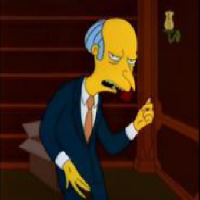

In [ ]:
test_image

In [ ]:
images = img_to_array(test_image)

In [ ]:
images.shape

(200, 200, 3)

In [ ]:
images

array([[[34.,  4.,  2.],
        [37.,  7.,  5.],
        [39.,  9.,  7.],
        ...,
        [34.,  6.,  5.],
        [24.,  6.,  6.],
        [10.,  0.,  0.]],

       [[35.,  5.,  3.],
        [37.,  7.,  5.],
        [39.,  9.,  7.],
        ...,
        [34.,  6.,  5.],
        [24.,  6.,  6.],
        [10.,  0.,  0.]],

       [[34.,  4.,  2.],
        [36.,  6.,  4.],
        [37.,  7.,  5.],
        ...,
        [34.,  6.,  5.],
        [24.,  6.,  6.],
        [10.,  0.,  0.]],

       ...,

       [[34., 18.,  2.],
        [37., 21.,  5.],
        [41., 24.,  6.],
        ...,
        [83., 26., 19.],
        [58., 23., 19.],
        [13.,  0.,  0.]],

       [[34., 18.,  2.],
        [37., 21.,  5.],
        [41., 24.,  6.],
        ...,
        [85., 27., 16.],
        [59., 24., 18.],
        [13.,  0.,  0.]],

       [[34., 18.,  2.],
        [37., 21.,  5.],
        [41., 24.,  6.],
        ...,
        [85., 27., 16.],
        [60., 26., 17.],
        [13.,  0.,  0.]]

Redimensionar la imagen

In [ ]:
images = np.expand_dims(images, axis=0)

In [ ]:
images

array([[[[34.,  4.,  2.],
         [37.,  7.,  5.],
         [39.,  9.,  7.],
         ...,
         [34.,  6.,  5.],
         [24.,  6.,  6.],
         [10.,  0.,  0.]],

        [[35.,  5.,  3.],
         [37.,  7.,  5.],
         [39.,  9.,  7.],
         ...,
         [34.,  6.,  5.],
         [24.,  6.,  6.],
         [10.,  0.,  0.]],

        [[34.,  4.,  2.],
         [36.,  6.,  4.],
         [37.,  7.,  5.],
         ...,
         [34.,  6.,  5.],
         [24.,  6.,  6.],
         [10.,  0.,  0.]],

        ...,

        [[34., 18.,  2.],
         [37., 21.,  5.],
         [41., 24.,  6.],
         ...,
         [83., 26., 19.],
         [58., 23., 19.],
         [13.,  0.,  0.]],

        [[34., 18.,  2.],
         [37., 21.,  5.],
         [41., 24.,  6.],
         ...,
         [85., 27., 16.],
         [59., 24., 18.],
         [13.,  0.,  0.]],

        [[34., 18.,  2.],
         [37., 21.,  5.],
         [41., 24.,  6.],
         ...,
         [85., 27., 16.],
        

In [ ]:
images.shape

(1, 200, 200, 3)

Predicción

In [ ]:
prediction = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [ ]:
prediction

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        2.0968094e-24, 0.0000000e+00, 1.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 5.0869825e-10, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 0.0000000e+00,
        6.9532866e-27, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00, 1.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 1.0000000e+00]], dtype=float32)

Verificamos que en este caso prediga que es charles_montgomery_burns

In [ ]:
predicted_class = np.argmax(prediction, axis=1)[0]

In [ ]:
if predicted_class == 6:
    print('Is charles_montgomery_burns')
else:
    print('Is not charles_montgomery_burns')

Is not charles_montgomery_burns


## Transfer Learning

In [64]:
batch_size = 32
img_height = 180
img_width = 180

In [65]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 36642 files belonging to 24 classes.
Using 29314 files for training.


In [66]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  validate_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 9161 files belonging to 24 classes.
Using 1832 files for validation.


In [67]:
class_names = train_ds.class_names
print(class_names)

['airport', 'bridge', 'commercial', 'dense', 'farmland', 'freeway', 'ground', 'harbor', 'industrial', 'intersection', 'mobile', 'overpass', 'park', 'parking', 'parkway', 'railway', 'railway_station', 'roundabout', 'shipping', 'sparse', 'stadium', 'storage', 'terrace', 'vegetable']


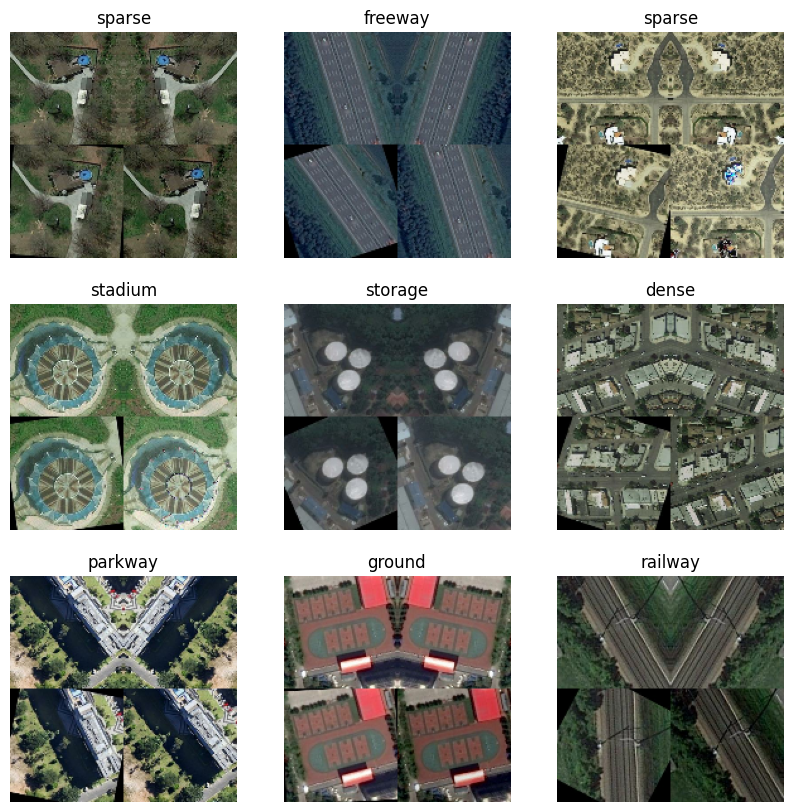

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [69]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [70]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [71]:
normalization_layer = layers.Rescaling(1./255)

In [72]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

KeyboardInterrupt: 

# Crear el modelo

In [73]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

c:\Users\aldol\diplo\lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



## Compilar el modelo

In [74]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [75]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,991,736 (15.23 MB)

 Trainable params: 3,991,736 (15.23 MB)

 Non-trainable params: 0 (0.00 B)

## Aumento de datos

In [79]:
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

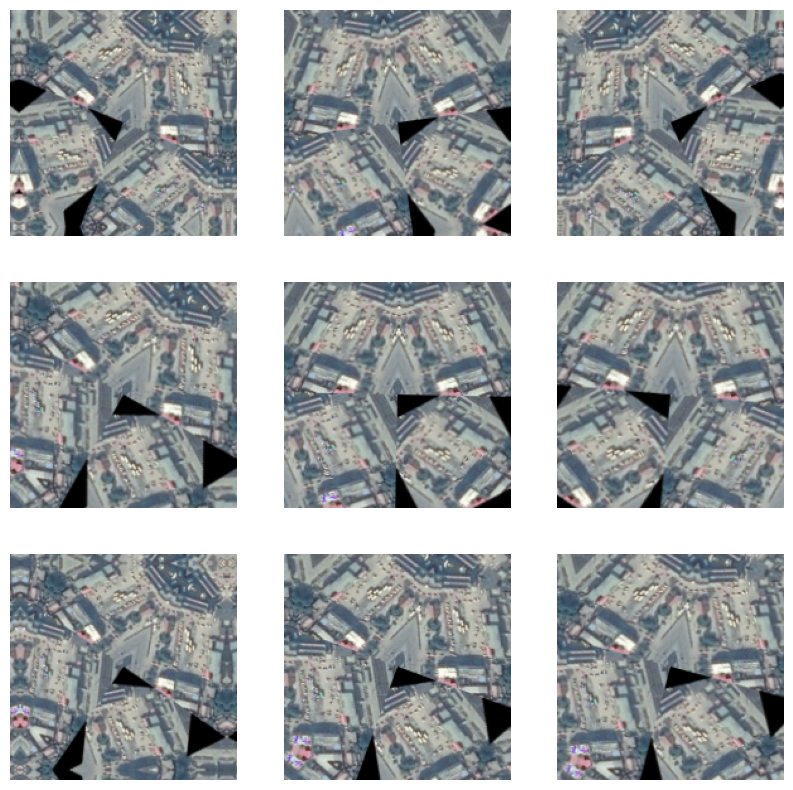

In [81]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(2):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [82]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [83]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [84]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 376s 408ms/step - accuracy: 0.2187 - loss: 2.6028 - val_accuracy: 0.3684 - val_loss: 2.1630
Epoch 2/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 366s 399ms/step - accuracy: 0.5242 - loss: 1.5715 - val_accuracy: 0.4345 - val_loss: 2.1277
Epoch 3/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 363s 396ms/step - accuracy: 0.6067 - loss: 1.2976 - val_accuracy: 0.4547 - val_loss: 1.9703
Epoch 4/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 366s 399ms/step - accuracy: 0.6527 - loss: 1.1282 - val_accuracy: 0.4159 - val_loss: 2.6137
Epoch 5/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 369s 402ms/step - accuracy: 0.6848 - loss: 1.0325 - val_accuracy: 0.4929 - val_loss: 1.9726
Epoch 6/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 366s 399ms/step - accuracy: 0.7131 - loss: 0.9345 - val_accuracy: 0.4787 - val_loss: 2.0245
Epoch 7/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 367s 400ms/step - accuracy: 0.7322 - loss: 0.8708 - val_accuracy: 0.4847 - val_loss: 2.0814
Epoch 8/15
917/917 ━━━━━━━━━━━━━━━━━━━━ 370s 403ms/step - accuracy: 0.7493 -

### Resultados de entrenamiento

In [86]:
results = pd.DataFrame(data = zip(history.history["loss"], history.history["val_loss"], history.history["accuracy"], history.history["val_accuracy"]), columns=["loss", "val_loss", "accuracy", "val_accuracy"])

In [87]:
results

,loss,val_loss,accuracy,val_accuracy
0,2.195108,2.163034,0.339906,0.368450
1,1.491800,2.127699,0.549021,0.434498
2,1.252545,1.970303,0.620386,0.454694
3,1.097960,2.613702,0.663369,0.415939
4,1.018407,1.972582,0.688272,0.492904
5,0.929066,2.024521,0.715221,0.478712
6,0.867922,2.081351,0.732073,0.484716
7,0.820452,2.063325,0.747527,0.474345
8,0.772413,2.050480,0.761752,0.499454
9,0.745533,1.916860,0.768745,0.522926


## Graficar métricas

In [88]:
cf.go_offline()
results.iplot(kind='line', title='Gráfica de Resultados')